In [1]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

path = "/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
grewpy.set_config('ud')
# path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/SUD_French-GSD-r2.15"
# grewpy.set_config('sud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

all_matches = corpus.search(grewpy.Request("pattern{X[upos<>PUNCT]}").without("X[InIdiom=Yes]").without("X[Idiom=Yes]").without("X[InTitle=Yes]").without("X[Title=Yes]").without("X[Scrap=Yes]").without("X[Foreign]").without("X[Lang]").without("X-[fixed]->Y").without("Y-[flat:name]->X").without("Y-[goeswith]->X") , clustering_parameter=['X.lemma'])
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value

# Create a dictionary to map sent_id to sentences for quick lookup
sent_id_to_sentence = {draft[i].meta['sent_id']: draft[i].features for i in range(len(draft))}

match_upos = {}
for key, value in matches.items():
    for m in value:
        match_sent_id = m['sent_id']
        match_node_index = str(m['matching']['nodes']['X'])
        if match_sent_id in sent_id_to_sentence:
            current_sentence_features = sent_id_to_sentence[match_sent_id]
            if match_node_index in current_sentence_features.keys():
                current_token_features = current_sentence_features[match_node_index]
                if 'ExtPos' in current_token_features:
                    match_upos.setdefault((key, current_token_features['ExtPos']), []).append(m)
                else:
                    match_upos.setdefault((key, current_token_features['upos']), []).append(m)
new_match_upos = {}
for key, value in match_upos.items():
    if len(value) > 10:
        new_match_upos[key] = value
match_upos = new_match_upos

connected to port: 59468


In [2]:
with open("../3. probability_matrix/patterns_all_nodes.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

data = { k : list() for k in match_upos }
for adv, mts in match_upos.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)

unique_lemma = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, match_upos in data.items() for m in match_upos for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_lemma) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

In [40]:
X = np.zeros((len(data.keys()), len(unique_features)))
for adv, samples in data.items():
    n_samples = len(match_upos)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = X[adv2idx[adv]] / n_samples
print(f"{X.shape=}")

X.shape=(2930, 438)


In [4]:
from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(n_neighbors=2, contamination=0.1)
clf.fit(X)

# Predict outliers 
y_pred = clf.fit_predict(X)

In [92]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.linalg import eig

def gaussian_kernel(xi, xj, sigma2):
    """Compute the Gaussian similarity between two points."""
    D = xi.shape[0]
    return (2 * np.pi * sigma2) ** (-D / 2) * np.exp(-np.linalg.norm(xi - xj) ** 2 / (2 * sigma2))

def quadratic_renyi_entropy(neighbors, X, sigma2):
    """Compute the quadratic Renyi entropy for a set of neighbors."""
    s = len(neighbors)
    entropy_sum = sum(
        gaussian_kernel(X[i], X[j], 2 * sigma2) for i in neighbors for j in neighbors
    )
    return -np.log(entropy_sum / (s ** 2))

import itertools

def get_optimal_subset(info_potential, k):
    # rank the total info potential left in the increasing order
    sorted_potential = sorted(info_potential.items(), key=lambda x: x[1])
    #removes objects behind the first significant gap as long as the number of remaining instances is no less than k
    #A significant gap is defined to have a value larger than the average gap.
    gaps = np.diff([x[1] for x in sorted_potential])
    avg_gap = np.mean(gaps) if len(gaps) > 0 else 0
    significant_gap_idx = next((i for i, g in enumerate(gaps) if g > avg_gap), len(sorted_potential) - k)
    # Keep at least k elements and remove those beyond the significant gap
    selected_neighbors = sorted_potential[:significant_gap_idx + 1]
    # Ensure at least k elements
    if len(selected_neighbors) < k:
        selected_neighbors = sorted_potential[:k]
    return list(selected_neighbors[-1][0])

def get_a(R):
    # n0 = number of columns in R (number of neighbouring instances in R)
    # e is a vector with all entries equal to 1 
    # A is R-Ree^T/N_o
    n0 = R.shape[1]
    e = np.ones((R.shape[1], 1))
    et = np.ones((1, R.shape[1]))
    a = R - R @ e @ et / n0
    return a

def get_b(R, outlier):
    """
    Compute the B matrix, where each column corresponds to the vector (o − x_i).

    Parameters:
    R (numpy.ndarray): Matrix of neighboring instances (columns are neighbors).
    outlier (numpy.ndarray): The outlier vector.

    Returns:
    numpy.ndarray: The B matrix.
    """
    # Initialize B as a matrix with the same number of columns as R
    B = np.zeros_like(R)

    # Compute each column of B
    for i in range(R.shape[1]):
        B[:, i] = outlier - R[:, i]

    return B

# def find_optimal_w(A, B):
#     """
#     Solve the generalized eigenvalue problem λ AAT w = BBT w.

#     Parameters:
#     A (numpy.ndarray): Matrix A derived from the neighboring set.
#     B (numpy.ndarray): Matrix B derived from the outlier and neighboring set.

#     Returns:
#     numpy.ndarray: The optimal direction w.
#     """
#     # Compute AAT and BBT
#     AAT = A @ A.T
#     AAT += np.eye(AAT.shape[0]) * 1e-6 # Regularization to avoid singularity
#     BBT = B @ B.T

#     # Solve the generalized eigenvalue problem: λ AAT w = BBT w
#     eigvals, eigvecs = eig(BBT, AAT)

#     # Find the eigenvector corresponding to the largest eigenvalue
#     max_eigval_index = np.argmax(eigvals)
#     w_optimal = eigvecs[:, max_eigval_index]

#     return w_optimal

def find_optimal_w_with_pseudo_inverse(A, B, variance_threshold=0.95):
    """
    Solve the generalized eigenvalue problem λ AAT w = BBT w using SVD and pseudo-inversion.

    Parameters:
    A (numpy.ndarray): Matrix A derived from the neighboring set.
    B (numpy.ndarray): Matrix B derived from the outlier and neighboring set.
    variance_threshold (float): The percentage of variance to retain in SVD.

    Returns:
    numpy.ndarray: The optimal direction w.
    """
    # Perform SVD on A
    U, Sigma, Vt = np.linalg.svd(A, full_matrices=False)

    # Compute the total variance and retain components explaining the desired variance
    total_variance = np.sum(Sigma ** 2)
    explained_variance = np.cumsum(Sigma ** 2) / total_variance
    num_components = np.searchsorted(explained_variance, variance_threshold) + 1

    # Retain only the leading singular values and vectors
    U = U[:, :num_components]
    Sigma = Sigma[:num_components]

    # Compute Σ^{-2}
    Sigma_inv_squared = np.diag(1 / (Sigma ** 2))

    # Compute U Σ^{-2} U^T
    pseudo_inverse_AAT = U @ Sigma_inv_squared @ U.T

    # Compute the matrix U Σ^{-2} U^T B B^T
    matrix_to_eigen = pseudo_inverse_AAT @ B @ B.T

    # Solve the eigenvalue problem for this matrix
    eigvals, eigvecs = np.linalg.eig(matrix_to_eigen)

    # Find the eigenvector corresponding to the largest eigenvalue
    max_eigval_index = np.argmax(eigvals)
    w_optimal = eigvecs[:, max_eigval_index]

    return w_optimal

def calculate_ad(w, o, R, var_r, epsilon=1e-8):
    """
    Calculate the statistical distance AD(o) for the outlier o.

    Parameters:
    w (numpy.ndarray): Optimal direction vector.
    o (numpy.ndarray): Outlier vector.
    R (numpy.ndarray): Matrix of neighboring instances (columns are neighbors).
    var_r (float): Variance of R(o) projected onto w.
    epsilon (float): Small regularization term to avoid division by zero.

    Returns:
    float: The statistical distance AD(o).
    """
    # Project o and R onto w
    w_to = w.T @ o
    w_tx = w.T @ R

    # Compute the center of the projected neighbors
    center = np.mean(w_tx)

    # Compute the first term of AD(o)
    numerator = (w_to - center) ** 2
    ad_o = np.sqrt(numerator / (var_r + epsilon))  # Add epsilon to avoid division by zero

    # Ensure AD(o) is not too close to the center
    ad_o = max(ad_o, np.sqrt(var_r + epsilon))

    return ad_o

def calculate_lad(ad_o, ad_neighbors):
    """
    Calculate the local anomalous degree LAD(o).

    Parameters:
    ad_o (float): Statistical distance AD(o) for the outlier.
    ad_neighbors (list of float): List of AD(x_i) for neighboring objects.

    Returns:
    float: The local anomalous degree LAD(o).
    """
    # Compute the average AD(x_i) for neighbors
    avg_ad_neighbors = np.mean(ad_neighbors)

    # Compute LAD(o)
    lad_o = ad_o / (avg_ad_neighbors + 1e-8)  # Add small epsilon to avoid division by zero

    return lad_o


def find_outlier_neighbors(X, k=2, sigma2=1.0):
    """
    Find an adaptive set of nearest neighbors for each outlier in X using local quadratic entropy.
    
    Parameters:
    X (numpy.ndarray): The dataset of shape (N, D).
    y_pred (list or numpy.ndarray): List of predictions, where -1 indicates an outlier and 1 an inlier.
    k (int): Minimum number of nearest neighbors.
    sigma2 (float): The variance parameter for the Gaussian kernel.
    
    Returns:
    dict: A dictionary where keys are outlier indices and values are lists of nearest neighbor indices.
    """
    s = 2 * k  # Initial number of nearest neighbors
    
    # Identify outlier indices
    # outlier_indices = np.where(y_pred == -1)[0]
    lad_scores = {}
    
    # Process each outlier
    for outlier_candidate_index in range(len(X)):
        outlier = X[outlier_candidate_index]
        cosine_similarities = []

        # Compute cosine similarity between the outlier and all other points
        for i in range(len(X)):
            print(i)
            cos_sim = cosine_similarity(outlier.reshape(1, -1), X[i].reshape(1, -1))[0][0]
            cosine_similarities.append((cos_sim, i))
        
        # Sort by similarity in descending order and select initial s neighbours
        cosine_similarities.sort(reverse=True, key=lambda x: x[0])
        neighbours = [idx for _, idx in cosine_similarities[1:s+1]]

        # Compute local information potential for subsets of neighbors
        info_potential = {}
        for l in range(len(neighbours)):
            new_list = neighbours[:(len(neighbours) - l)]
            info_potential[tuple(new_list)] = quadratic_renyi_entropy(new_list, X, sigma2)
        
        # Find the optimal subset of neighbors
        optimal_subset = get_optimal_subset(info_potential, k)

        # Create the R matrix
        R = np.array([X[i] for i in optimal_subset]).T
        A = get_a(R)

        # Compute the B matrix
        B = get_b(R, outlier)

        # Find the optimal direction w
        # w_optimal = find_optimal_w(A, B)
        w_optimal = find_optimal_w_with_pseudo_inverse(A, B, variance_threshold=0.95)
        # Compute the variance of R(o) projected onto w
        var_r = w_optimal.T @ A @ A.T @ w_optimal

        # Compute the distance between the outlier and every point in the optimal subset
        d = w_optimal.T @ B @ B.T @ w_optimal

        # Compute AD(o)
        ad_o = calculate_ad(w_optimal, outlier, R, var_r)

        # Compute AD(x_i) for neighbors
        ad_neighbors = [calculate_ad(w_optimal, X[i], R, var_r) for i in optimal_subset]

        # Compute LAD(o)
        lad_o = calculate_lad(ad_o, ad_neighbors)

        # Store LAD score for the outlier
        lad_scores[outlier_index] = lad_o

    return lad_scores

        # we want to learn a direction for w such that the variance of R(o) projected onto it is minimized 
        # whereas the variance between o and R(o) also projected on that direction is maximized
        # One possible way to do that is to form an objective function resembling Rayleigh’s quotient which maximizes the ratio between D(o,R(o)) and R(o)
        # argmax_wJ(w)=\frac{D_{(o,R(o))}}{Var(R(o))} = \frac{w^TBB^Tw}{wT^AATw}




        # for sublist in neighbour_subsets:
        #     if len(sublist) < k:
        #         continue
        #     # Compute local information potential for all s neighbors
        #     print(f"sublist: {sublist}")
        #     info_potential[tuple(sublist)] = quadratic_renyi_entropy(sublist, X, sigma2)
        # print(f"info_potential: {info_potential}")
        

        # calculate cosine similarity between outlier and all other points
        



    #     neighbour_subsets[outlier] = []
        
    #     for i in range(len(X)):
    #         potential_neighbours_index = [i]
    #         for j in range(k):
    #             potential_neighbours_index.append[j]
    #             if i != outlier:
    #                 potential_neighbours = [X]
    #                 sim = quadratic_renyi_entropy(X[outlier], X[index], sigma2)
    #                 similarities.append((sim, i))
        
    #     # Sort by similarity in descending order and select initial s neighbors
    #     similarities.sort(reverse=True, key=lambda x: x[0])
    #     neighbors = [idx for _, idx in similarities[:s]]
        
    #     # Compute local information potential for all s neighbors
    #     total_potentials = [sum(gaussian_kernel(X[idx], X[j], sigma2) for j in neighbors if j != idx) for idx in neighbors]
        
    #     # Compute gaps and find significant gap threshold
    #     gaps = np.diff(sorted(total_potentials))
    #     avg_gap = np.mean(gaps) if len(gaps) > 0 else 0
    #     significant_gap_idx = next((i for i, g in enumerate(gaps) if g > avg_gap), len(neighbors) - k)
        
    #     # Keep at least k elements and remove those beyond the significant gap
    #     selected_neighbors = sorted(neighbors, key=lambda idx: total_potentials[neighbors.index(idx)])[:significant_gap_idx + 1]
    #     outlier_neighbors[outlier] = selected_neighbors if len(selected_neighbors) >= k else neighbors[:k]
    
    # return outlier_neighbors
lad_scores = find_outlier_neighbors(X,  k=5, sigma2=1.0)

# Print LAD scores for all outliers
for outlier_index, lad_score in lad_scores.items():
    print(f"Outlier Index: {outlier_index}, LAD Score: {lad_score}")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Generate the two moons dataset
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# # Inject some artificial anomalies
# num_outliers = 10
# outliers = np.random.uniform(low=-2, high=3, size=(num_outliers, 2))
# X = np.vstack([X, outliers])

# # Scale the dataset for better performance
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# # Use Isolation Forest to identify potential outliers
# clf = IsolationForest(contamination=0.05, random_state=42)
# y_pred = clf.fit_predict(X)

# Run your anomaly detection algorithm
lad_scores = find_outlier_neighbors(X,  k=5, sigma2=1.0)

# # Plot results
# plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='coolwarm', edgecolors='k')
# plt.colorbar(label='Predicted Label (-1: Outlier, 1: Inlier)')
# plt.scatter(X[y_pred == -1][:, 0], X[y_pred == -1][:, 1], c='yellow', edgecolors='black', marker='x', label='Detected Outliers')
# plt.legend()
# plt.title('Two Moons Dataset with Anomalies')
# plt.show()

# Print LAD scores
for outlier_index, lad_score in lad_scores.items():
    print(f"Outlier Index: {outlier_index}, LAD Score: {lad_score}")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [89]:
lad_scores

{567: 2.243984274935922}

In [ ]:
X[]

(2930, 438)

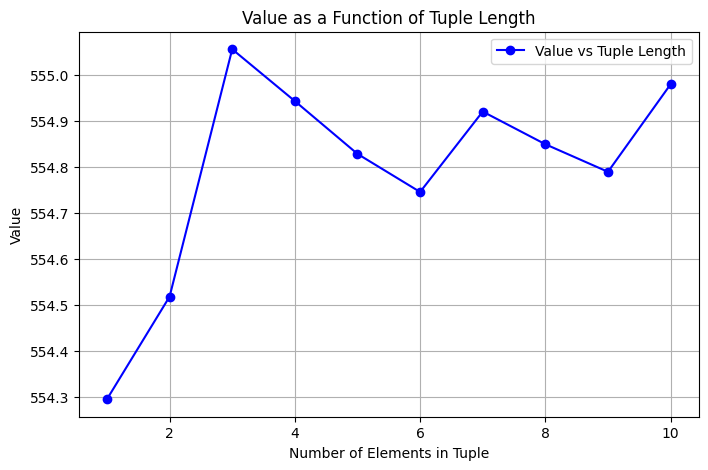

In [74]:
# plot the value in function of the number of elements in the tuple
# l = {(999, 2582, 2834, 2769, 902, 2764, 974, 1983, 802, 979): 554.9802996404087, (999, 2582, 2834, 2769, 902, 2764, 974, 1983, 802): 554.7896357745201, (999, 2582, 2834, 2769, 902, 2764, 974, 1983): 554.8497233062975, (999, 2582, 2834, 2769, 902, 2764, 974): 554.920869382136, (999, 2582, 2834, 2769, 902, 2764): 554.7457312960605, (999, 2582, 2834, 2769, 902): 554.8286939320672}
import matplotlib.pyplot as plt

x = [len(t) for t in l.keys()]  # Number of elements in each tuple
y = list(l.values())  # Corresponding values

# Plot the data
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Value vs Tuple Length')
plt.xlabel('Number of Elements in Tuple')
plt.ylabel('Value')
plt.title('Value as a Function of Tuple Length')
plt.grid(True)
plt.legend()
plt.show()


In [39]:
X = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
# make an array with y just line 1 and 3 from x
y = np.array([X[0], X[2], X[1]])
y

array([[1, 2, 3],
       [7, 8, 9],
       [4, 5, 6]])

In [26]:
idx2adv[2834]

('à', 'ADP')

I have a matrix X whichhas D = 438 and N = 2930. So my matrix X = {x1, x2...xN} is a dataset of N instances and each xi is represented as factor in a D-dimensional space. Each dimension represents a feature f1 to fD.
The quadratic Renyi entropy is calculated using this formula: QE(R(o))=-ln\frac{1}{s^2}\sum^{s}_{i}\sum^{s}_{j}{G(x_i-x_j, 2σ^2)}
where G(x_i-x_j, σ^2) = (2πσ)^{-D/2}exp\{\frac{||x_i-x_j||^2}{2σ^2}\} and R(o) = {x1, x2, . . . , xs} a set of neearest neighboring instances closest to an outlier candidate o.
I want a python function that takes X as input and a list y_pred which looks like this [1, -1, -1, 1...] -1 indicating that the element at that index is an outlier and 1 an inlier. The function should output a dictionary where the key is the index of the outlier and the value a list of indexes of nearest neighbours.

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal

def gaussian_kernel(x, xi, sigma):
    """
    Gaussian kernel function.

    Parameters:
    x (numpy array): Point at which to evaluate the kernel.
    xi (numpy array): Center of the kernel.
    sigma (float): Standard deviation of the Gaussian kernel.

    Returns:
    float: Value of the Gaussian kernel at point x.
    """
    D = len(x)
    coeff = (1 / (np.sqrt(2 * np.pi) * sigma)) ** D
    exponent = -0.5 * np.sum((x - xi) ** 2) / (sigma ** 2)
    return coeff * np.exp(exponent)

def estimate_pdf(data, x, sigma):
    """
    Estimate the PDF using the Parzen window technique.

    Parameters:
    data (numpy array): Array of data points.
    x (numpy array): Point at which to estimate the PDF.
    sigma (float): Standard deviation of the Gaussian kernel.

    Returns:
    float: Estimated PDF value at point x.
    """
    s = len(data)
    pdf_value = np.sum(gaussian_kernel(x, xi, sigma) for xi in data) / s
    return pdf_value

def local_quadratic_renyi_entropy(data, sigma):
    """
    Compute the local quadratic Renyi entropy.

    Parameters:
    data (numpy array): Array of data points.
    sigma (float): Standard deviation of the Gaussian kernel.

    Returns:
    float: Local quadratic Renyi entropy value.
    """
    s = len(data)
    integrand_sum = 0

    for x in data:
        pdf_value_x = estimate_pdf(data, x, sigma)
        integrand_sum += pdf_value_x ** 2

    integrand = integrand_sum / s
    renyi_entropy_value = -np.log(integrand)
    return renyi_entropy_value

In [ ]:
def compute_entropy_decrement(data, sigma, index_to_remove):
    """
    Compute the decrement in entropy when a specific data point is removed.

    Parameters:
    data (numpy array): Array of data points.
    sigma (float): Standard deviation of the Gaussian kernel.
    index_to_remove (int): Index of the data point to remove.

    Returns:
    float: Decrement in entropy.
    """
    reduced_data = np.delete(data, index_to_remove, axis=0)
    entropy_reduced = local_quadratic_renyi_entropy(reduced_data, sigma)
    entropy_full = local_quadratic_renyi_entropy(data, sigma)
    return entropy_full - entropy_reduced

def select_optimal_neighbors(data, sigma, k):
    """
    Select an optimal subset of neighbors based on local quadratic Renyi entropy.

    Parameters:
    data (numpy array): Array of data points.
    sigma (float): Standard deviation of the Gaussian kernel.
    k (int): Minimum number of neighbors to retain.

    Returns:
    numpy array: Optimal subset of neighbors.
    """
    s = len(data)
    if s <= k:
        return data  # Not enough data to remove any points

    # Compute entropy decrement for each neighbor
    entropy_decrements = [compute_entropy_decrement(data, sigma, i) for i in range(s)]

    # Sort indices by entropy decrement in increasing order
    sorted_indices = np.argsort(entropy_decrements)

    # Find the significant gap
    gaps = np.diff(np.sort(entropy_decrements))
    average_gap = np.mean(gaps)
    significant_gap_index = next((i for i, gap in enumerate(gaps) if gap > average_gap), len(gaps))

    # Determine the cutoff index
    cutoff_index = max(significant_gap_index + 1, s - k)

    # Select the optimal subset
    optimal_indices = sorted_indices[:cutoff_index]
    optimal_neighbors = data[optimal_indices]

    return optimal_neighbors



In [ ]:
def compute_variance(R, w):
    """
    Compute the variance of neighboring objects projected onto the subspace w.

    Parameters:
    R (numpy array): Array of neighboring data points.
    w (numpy array): The 1-dimensional subspace vector.

    Returns:
    float: Variance of the projected neighboring objects.
    """
    N_o = R.shape[0]
    e = np.ones((N_o, 1))
    R_mean = (R @ e @ e.T) / N_o
    A = R - R_mean
    variance = w.T @ A @ A.T @ w
    return variance

def find_optimal_subspace(R, o):
    """
    Find the optimal 1-dimensional subspace w that maximizes the separation of o from R.

    Parameters:
    R (numpy array): Array of neighboring data points.
    o (numpy array): The outlier candidate.

    Returns:
    numpy array: The optimal 1-dimensional subspace vector w.
    """
    # Center the data
    R_centered = R - R.mean(axis=0)
    o_centered = o - R.mean(axis=0)

    # Compute the covariance matrix of the centered neighbors
    cov_matrix = R_centered.T @ R_centered

    # The optimal subspace w is the eigenvector corresponding to the largest eigenvalue
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    w = eigenvectors[:, -1]

    return w

def compute_distance_variance(o, R, w):
    """
    Compute the variance of distances between the outlier o and its neighbors R in the projected dimension w.

    Parameters:
    o (numpy array): The outlier candidate.
    R (numpy array): Array of neighboring data points.
    w (numpy array): The 1-dimensional subspace vector.

    Returns:
    float: Variance of the distances in the projected dimension.
    """
    # Compute the matrix B where each column is (o - x_i)
    B = o.reshape(-1, 1) - R

    # Compute the variance of distances in the projected dimension w
    distance_variance = w.T @ B @ B.T @ w
    return distance_variance